# Extended functional specialization (5 per schedule, 14 runs)

Runs the specialization pipeline (retraining, correlation, ablations) on **5 participants per schedule** (same, near, far) for each run configuration, then presents individual and averaged results in tables and figures sorted by sparsity and input scheme.

**Run configurations:** No comms (2), sparsity 0.1 (2), 0.3 (2), 0.5 (2), 0.7 (2), 0.9 (2), full (2) — each with shared and task_routed input.

## 1. Setup and imports

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import ConcatDataset, DataLoader
from tqdm.auto import tqdm

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

data_folder = project_root / "data"
sim_folder = data_folder / "simulations"

from a1b2.analysis import transfer_interference as ann
from a1b2.analysis import run_loader
from a1b2.analysis.retraining_a1b2 import (
    create_retraining_model_a1b2,
    train_probe_readout_a1b2,
    eval_probe_readout_a1b2,
    retraining_specialization_scalar,
    compute_ablations_metric_a1b2,
)
from a1b2.analysis.correlations_a1b2 import compute_correlation_metric_a1b2
from a1b2.data.basic_funcs import get_datasets
from a1b2.models.ffn import CreateParticipantDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
project_root, data_folder, sim_folder, device

/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular'),
 PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data'),
 PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations'),
 device(type='cuda'))

## 2. Run configuration

Define the run prefixes and canonical ordering (sparsity then input_scheme) for sorting and plotting. Includes no_comms, 0.1, 0.3, 0.5, 0.7, 0.9, full (shared and task_routed each).

In [2]:
# (prefix, sparsity_label, input_scheme) in display order: no_comms -> 0.1 -> 0.3 -> 0.5 -> 0.7 -> 0.9 -> full; within each, shared then task_routed
RUN_CONFIG = [
    ("two_module_rnn_25_no_comms_nb2", "no_comms", "shared"),
    ("two_module_rnn_25_task_routed_no_comms_nb2", "no_comms", "task_routed"),
    ("two_module_rnn_25_sp01_nb2", "0.1", "shared"),
    ("two_module_rnn_25_task_routed_sp01_nb2", "0.1", "task_routed"),
    ("two_module_rnn_25_low_sparse_nb2", "0.3", "shared"),
    ("two_module_rnn_25_task_routed_low_sparse_nb2", "0.3", "task_routed"),
    ("two_module_rnn_25_sp05_nb2", "0.5", "shared"),
    ("two_module_rnn_25_task_routed_sp05_nb2", "0.5", "task_routed"),
    ("two_module_rnn_25_sp07_nb2", "0.7", "shared"),
    ("two_module_rnn_25_task_routed_sp07_nb2", "0.7", "task_routed"),
    ("two_module_rnn_25_sp09_nb2", "0.9", "shared"),
    ("two_module_rnn_25_task_routed_sp09_nb2", "0.9", "task_routed"),
    ("two_module_rnn_25_nb2", "full", "shared"),
    ("two_module_rnn_25_task_routed_nb2", "full", "task_routed"),
]

def resolve_run(prefix):
    if not sim_folder.exists():
        raise FileNotFoundError(f"Simulations folder not found: {sim_folder}")
    candidates = sorted([p for p in sim_folder.iterdir() if p.is_dir() and p.name.startswith(prefix)])
    if not candidates:
        return None
    return candidates[0]

runs = []
for prefix, sparsity_label, input_scheme in RUN_CONFIG:
    path = resolve_run(prefix)
    if path is not None:
        runs.append({"run_id": prefix, "path": path, "sparsity_label": sparsity_label, "input_scheme": input_scheme})
    else:
        print(f"Skip {prefix}: no matching folder.")
runs

[{'run_id': 'two_module_rnn_25_no_comms_nb2',
  'path': PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/two_module_rnn_25_no_comms_nb2_nb2_shared_sp0_sep_cr_RNN'),
  'sparsity_label': 'no_comms',
  'input_scheme': 'shared'},
 {'run_id': 'two_module_rnn_25_task_routed_no_comms_nb2',
  'path': PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/two_module_rnn_25_task_routed_no_comms_nb2_nb2_task_routed_sp0_sep_cr_RNN'),
  'sparsity_label': 'no_comms',
  'input_scheme': 'task_routed'},
 {'run_id': 'two_module_rnn_25_sp01_nb2',
  'path': PosixPath('/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations/two_module_rnn_25_sp01_nb2_nb2_shared_sp0.1_sep_cr_RNN'),
  'sparsity_label': '0.1',
  'input_scheme': 'shared'},
 {'run_id': 'two_module_rnn_25_task_routed_sp01_nb2',
  'path': PosixPath('/home/kat/workspace/Structure-Function

## 3. Participant selection (5 per schedule)

For each run: get participants (state+npz or npz-only), parse schedule from id, take first 5 per schedule (same, near, far).

In [3]:
def participant_id_to_schedule(pid):
    pid = str(pid).lower()
    if "same" in pid:
        return "same"
    if "near" in pid:
        return "near"
    if "far" in pid:
        return "far"
    return None

def get_tasks_for_run(r):
    """Return list of (run_dict, participant, schedule) for one run (5 per schedule)."""
    run_path = r["path"]
    candidates = run_loader.list_participants_with_state(run_path)
    if not candidates:
        candidates = run_loader.list_participants_with_npz(run_path)
    candidates = sorted([p for p in candidates if p in participants_in_trial])
    by_schedule = {"same": [], "near": [], "far": []}
    for p in candidates:
        s = participant_id_to_schedule(p)
        if s and len(by_schedule[s]) < N_PER_SCHEDULE:
            by_schedule[s].append(p)
    out = []
    for schedule in ["same", "near", "far"]:
        for participant in by_schedule[schedule]:
            out.append((r, participant, schedule))
    return out

N_PER_SCHEDULE = 5
df_trial = ann.load_participant_data(str(data_folder))
participants_in_trial = set(df_trial["participant"].unique())

tasks = []
tasks_by_run = {}  # run_id -> list of (run_dict, participant, schedule)
for r in runs:
    run_path = r["path"]
    candidates = run_loader.list_participants_with_state(run_path)
    if not candidates:
        candidates = run_loader.list_participants_with_npz(run_path)
    candidates = sorted([p for p in candidates if p in participants_in_trial])
    by_schedule = {"same": [], "near": [], "far": []}
    for p in candidates:
        s = participant_id_to_schedule(p)
        if s and len(by_schedule[s]) < N_PER_SCHEDULE:
            by_schedule[s].append(p)
    this_run_tasks = []
    for schedule in ["same", "near", "far"]:
        for participant in by_schedule[schedule]:
            t = (r, participant, schedule)
            tasks.append(t)
            this_run_tasks.append(t)
    tasks_by_run[r["run_id"]] = this_run_tasks

print(f"Total tasks: {len(tasks)} (runs × participants)")
print(f"Participants per run: {len(tasks) // len(runs) if runs else 0}")

Total tasks: 179 (runs × participants)
Participants per run: 12


## 4. Helper: build loader

In [4]:
def build_loader_for_participant(df, participant, task_parameters, batch_size=32, shuffle=False):
    dataset_A1, dataset_B, dataset_A2, _, _ = get_datasets(df, participant, task_parameters)
    combined = ConcatDataset([
        CreateParticipantDataset(dataset_A1),
        CreateParticipantDataset(dataset_B),
        CreateParticipantDataset(dataset_A2),
    ])
    return DataLoader(combined, batch_size=batch_size, shuffle=shuffle)

## 5. Compute metrics (per configuration)

Run **one cell per configuration** so you can run only a subset (e.g. no_comms first). Re-running a configuration cell replaces that run's results. After running the configs you want, run **Build df_results** below, then Tables and Figures.

In [5]:
# Run once to start; re-run to clear all results before re-running configs.
results_list = []
n_epochs_probe = 1

# Map prefix -> (sparsity_label, input_scheme) so we can resolve by run_id when a run was skipped at load time
RUN_CONFIG_BY_PREFIX = {prefix: (s, i) for prefix, s, i in RUN_CONFIG}

def run_metrics_for_config(run_id_or_idx):
    """Run specialization metrics for one config. Pass run_id (e.g. 'two_module_rnn_25_sp01_nb2') or index 0..13. Re-running replaces that run's results."""
    if isinstance(run_id_or_idx, int):
        if run_id_or_idx < 0 or run_id_or_idx >= len(runs):
            print(f"run_idx must be 0..{len(runs)-1}")
            return
        r = runs[run_id_or_idx]
    else:
        run_id = run_id_or_idx
        r = next((x for x in runs if x["run_id"] == run_id), None)
        if r is None:
            path = resolve_run(run_id)
            if path is None:
                print(f"Run {run_id!r}: no matching folder in {sim_folder}. Run 02_run_simulations.py first.")
                return
            if run_id not in RUN_CONFIG_BY_PREFIX:
                print(f"Run {run_id!r}: not in RUN_CONFIG.")
                return
            sparsity_label, input_scheme = RUN_CONFIG_BY_PREFIX[run_id]
            r = {"run_id": run_id, "path": path, "sparsity_label": sparsity_label, "input_scheme": input_scheme}
            tasks_by_run[run_id] = get_tasks_for_run(r)
    run_id = r["run_id"]
    tasks_this_run = tasks_by_run.get(run_id, [])
    if not tasks_this_run:
        print(f"Run {run_id}: no participants (folder empty or no overlap with trial data).")
        return
    # Replace any existing results for this run
    results_list[:] = [row for row in results_list if row["run_id"] != run_id]
    for r, participant, schedule in tqdm(tasks_this_run, desc=f"Run {run_id}"):
        run_path = r["path"]
        sparsity_label = r["sparsity_label"]
        input_scheme = r["input_scheme"]
        settings = run_loader.load_settings(run_path)
        task_parameters = settings.get("task_parameters") or ann.setup_task_parameters()
        row = {
            "run_id": run_id,
            "participant": participant,
            "schedule": schedule,
            "sparsity_label": sparsity_label,
            "input_scheme": input_scheme,
            "retraining_specialization": None,
            "correlation_specialization": None,
            "ablation_specialization": None,
        }
        has_state = (run_path / f"state_{participant}.pt").exists()
        if has_state:
            loader = build_loader_for_participant(df_trial, participant, task_parameters, batch_size=32, shuffle=True)
            wrapper = run_loader.build_wrapper_from_settings(settings, device=device)
            run_loader.load_wrapper_state(wrapper, run_path / f"state_{participant}.pt")
            wrapper = create_retraining_model_a1b2(wrapper, device=device)
            wrapper = train_probe_readout_a1b2(wrapper, loader, settings.get("condition", {}), n_epochs=n_epochs_probe, lr=1e-3, device=device)
            acc = eval_probe_readout_a1b2(wrapper, loader, device=device)
            row["retraining_specialization"] = float(retraining_specialization_scalar(acc[0, 0], acc[1, 0], acc[0, 1], acc[1, 1]))
            ab = compute_ablations_metric_a1b2(wrapper, loader, device=device)
            row["ablation_specialization"] = float(ab["ablation_specialization"])
        npz_path = run_path / f"sim_{participant}.npz"
        if npz_path.exists():
            with np.load(npz_path, allow_pickle=True) as data:
                if "hiddens_per_module" in data and "probes" in data:
                    participant_data = {"hiddens_per_module": data["hiddens_per_module"], "probes": data["probes"], "inputs": data["inputs"]}
                    out = compute_correlation_metric_a1b2(participant_data, n_samples=5)
                    row["correlation_specialization"] = float(out["correlation_specialization"])
        results_list.append(row)
    print(f"Run {run_id}: {len(tasks_this_run)} participants appended. Total results: {len(results_list)}")

In [6]:
# Optional: clear all results and start over (then re-run only the config cells you want).
results_list = []
print("results_list cleared.")

results_list cleared.


In [7]:
run_metrics_for_config(0)  # no_comms shared

Run two_module_rnn_25_no_comms_nb2: 100%|██████████| 15/15 [2:07:13<00:00, 508.88s/it]

Run two_module_rnn_25_no_comms_nb2: 15 participants appended. Total results: 15


In [8]:
run_metrics_for_config(1)  # no_comms task_routed

Run two_module_rnn_25_task_routed_no_comms_nb2:   0%|          | 0/15 [00:00<?, ?it/s]/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Run two_module_rnn_25_task_routed_no_comms_nb2: 100%|██████████| 15/15 [2:07:18<00:00, 509.24s/it]

Run two_module_rnn_25_task_routed_no_comms_nb2: 15 participants appended. Total results: 30


In [9]:
#run_metrics_for_config("two_module_rnn_25_sp01_nb2")  # 0.1 shared

In [10]:
#run_metrics_for_config("two_module_rnn_25_task_routed_sp01_nb2")  # 0.1 task_routed

In [11]:
run_metrics_for_config(4)  # 0.3 shared

Run two_module_rnn_25_low_sparse_nb2: 100%|██████████| 15/15 [2:07:46<00:00, 511.12s/it] 

Run two_module_rnn_25_low_sparse_nb2: 15 participants appended. Total results: 45


In [12]:
run_metrics_for_config(5)  # 0.3 task_routed

Run two_module_rnn_25_task_routed_low_sparse_nb2: 100%|██████████| 15/15 [2:02:24<00:00, 489.66s/it]

Run two_module_rnn_25_task_routed_low_sparse_nb2: 15 participants appended. Total results: 60


In [13]:
run_metrics_for_config(6)  # 0.5 shared

Run two_module_rnn_25_sp05_nb2: 100%|██████████| 15/15 [1:42:29<00:00, 409.98s/it]

Run two_module_rnn_25_sp05_nb2: 15 participants appended. Total results: 75


In [14]:
run_metrics_for_config(7)  # 0.5 task_routed

Run two_module_rnn_25_task_routed_sp05_nb2: 100%|██████████| 15/15 [1:42:43<00:00, 410.92s/it]

Run two_module_rnn_25_task_routed_sp05_nb2: 15 participants appended. Total results: 90


In [15]:
run_metrics_for_config(8)  # 0.7 shared

Run two_module_rnn_25_sp07_nb2: 100%|██████████| 15/15 [1:42:46<00:00, 411.10s/it]

Run two_module_rnn_25_sp07_nb2: 15 participants appended. Total results: 105


In [16]:
run_metrics_for_config(9)  # 0.7 task_routed

Run two_module_rnn_25_task_routed_sp07_nb2: 100%|██████████| 15/15 [1:42:38<00:00, 410.57s/it]

Run two_module_rnn_25_task_routed_sp07_nb2: 15 participants appended. Total results: 120


In [17]:
#run_metrics_for_config("two_module_rnn_25_sp09_nb2")  # 0.9 shared

In [18]:
#run_metrics_for_config("two_module_rnn_25_task_routed_sp09_nb2")  # 0.9 task_routed

In [19]:
run_metrics_for_config(12)  # full shared

Run two_module_rnn_25_nb2: 100%|██████████| 15/15 [1:42:47<00:00, 411.13s/it]

Run two_module_rnn_25_nb2: 15 participants appended. Total results: 135


In [20]:
run_metrics_for_config(13)  # full task_routed

Run two_module_rnn_25_task_routed_nb2: 100%|██████████| 15/15 [1:42:49<00:00, 411.30s/it]

Run two_module_rnn_25_task_routed_nb2: 15 participants appended. Total results: 150


In [28]:
run_metrics_for_config("two_module_rnn_25_sp01_nb2")  # 0.1 shared

Run two_module_rnn_25_sp01_nb2: 100%|██████████| 8/8 [54:49<00:00, 411.17s/it]

Run two_module_rnn_25_sp01_nb2: 8 participants appended. Total results: 172


In [29]:
run_metrics_for_config("two_module_rnn_25_task_routed_sp01_nb2")  # 0.1 task_routed

Run two_module_rnn_25_task_routed_sp01_nb2: 100%|██████████| 7/7 [48:07<00:00, 412.46s/it]

Run two_module_rnn_25_task_routed_sp01_nb2: 7 participants appended. Total results: 179


In [26]:
run_metrics_for_config("two_module_rnn_25_sp09_nb2")  # 0.9 shared

Run two_module_rnn_25_sp09_nb2: 100%|██████████| 7/7 [48:22<00:00, 414.67s/it]

Run two_module_rnn_25_sp09_nb2: 7 participants appended. Total results: 157


In [27]:
run_metrics_for_config("two_module_rnn_25_task_routed_sp09_nb2")  # 0.9 task_routed

Run two_module_rnn_25_task_routed_sp09_nb2: 100%|██████████| 7/7 [48:00<00:00, 411.47s/it]

Run two_module_rnn_25_task_routed_sp09_nb2: 7 participants appended. Total results: 164


### Build DataFrame

Run this after one or more config cells. Tables and Figures below use `df_results`.

In [30]:
df_results = pd.DataFrame(results_list).drop_duplicates(subset=["run_id", "participant"], keep="last")
print(f"df_results: {len(df_results)} rows.")

df_results: 179 rows.


In [31]:
## 6. Tables

#Individual, run-level mean (SEM), and by-schedule mean (SEM), sorted by sparsity then input_scheme.

In [36]:
metric_cols = ["retraining_specialization", "correlation_specialization", "ablation_specialization"]
sparsity_order = {"no_comms": 0, "0.1": 1, "0.3": 2, "0.5": 3, "0.7": 4, "0.9": 5, "full": 6}
if len(df_results) == 0:
    print("No results yet. Run at least one 'Run metrics' config cell (and the init cell), then Build DataFrame.")
    df_sorted = pd.DataFrame()
    run_level = pd.DataFrame()
    by_schedule = pd.DataFrame()
else:
    df_results["sparsity_order"] = df_results["sparsity_label"].map(sparsity_order)
    df_sorted = df_results.sort_values(["sparsity_order", "input_scheme", "run_id", "schedule", "participant"]).drop(columns=["sparsity_order"])

    print("Individual results (first rows):")
    display(df_sorted.head(20))

    run_level = df_sorted.groupby(["run_id", "sparsity_label", "input_scheme"], sort=False)[metric_cols].agg(["mean", "sem", "count"]).reset_index()
    run_level["_so"] = run_level["sparsity_label"].map(sparsity_order)
    run_level = run_level.sort_values(["_so", "input_scheme"]).drop(columns=["_so"])
    print("\nRun-level mean (SEM), n:")
    display(run_level)

    by_schedule = df_sorted.groupby(["run_id", "sparsity_label", "input_scheme", "schedule"], sort=False)[metric_cols].agg(["mean", "sem", "count"]).reset_index()
    by_schedule["_so"] = by_schedule["sparsity_label"].map(sparsity_order)
    by_schedule = by_schedule.sort_values(["_so", "input_scheme", "schedule"]).drop(columns=["_so"])
    print("\nBy run_id and schedule (mean, SEM, n):")
    display(by_schedule)

Individual results (first rows):


,run_id,participant,schedule,sparsity_label,input_scheme,retraining_specialization,correlation_specialization,ablation_specialization
10,two_module_rnn_25_no_comms_nb2,study1_far_sub1,far,no_comms,shared,NaN,0.0,NaN
11,two_module_rnn_25_no_comms_nb2,study1_far_sub10,far,no_comms,shared,NaN,0.0,NaN
12,two_module_rnn_25_no_comms_nb2,study1_far_sub12,far,no_comms,shared,NaN,0.0,NaN
13,two_module_rnn_25_no_comms_nb2,study1_far_sub13,far,no_comms,shared,NaN,0.0,NaN
14,two_module_rnn_25_no_comms_nb2,study1_far_sub15,far,no_comms,shared,NaN,0.0,NaN
5,two_module_rnn_25_no_comms_nb2,study1_near_sub1,near,no_comms,shared,NaN,0.0,NaN
6,two_module_rnn_25_no_comms_nb2,study1_near_sub10,near,no_comms,shared,NaN,0.0,NaN
7,two_module_rnn_25_no_comms_nb2,study1_near_sub14,near,no_comms,shared,NaN,0.0,NaN
8,two_module_rnn_25_no_comms_nb2,study1_near_sub15,near,no_comms,shared,NaN,0.0,NaN
9,two_module_rnn_25_no_comms_nb2,study1_near_sub18,near,no_comms,shared,NaN,0.0,NaN



Run-level mean (SEM), n:


/tmp/ipykernel_3664421/3986178902.py:17: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  run_level = run_level.sort_values(["_so", "input_scheme"]).drop(columns=["_so"])


run_id sparsity_label input_scheme  \
                                                                               
0                 two_module_rnn_25_no_comms_nb2       no_comms       shared   
1     two_module_rnn_25_task_routed_no_comms_nb2       no_comms  task_routed   
2                     two_module_rnn_25_sp01_nb2            0.1       shared   
3         two_module_rnn_25_task_routed_sp01_nb2            0.1  task_routed   
4               two_module_rnn_25_low_sparse_nb2            0.3       shared   
5   two_module_rnn_25_task_routed_low_sparse_nb2            0.3  task_routed   
6                     two_module_rnn_25_sp05_nb2            0.5       shared   
7         two_module_rnn_25_task_routed_sp05_nb2            0.5  task_routed   
8                     two_module_rnn_25_sp07_nb2            0.7       shared   
9         two_module_rnn_25_task_routed_sp07_nb2            0.7  task_routed   
10                    two_module_rnn_25_sp09_nb2            0.9       shared   
11        two_module_rnn_25_task_routed_sp09_nb2            0.9  task_routed   
12                         two_module_rnn_25_nb2           full       shared   
13             two_module_rnn_25_task_routed_nb2           full  task_routed   

   retraining_specialization                 correlation_specialization  \
                        mean       sem count                       mean   
0                        NaN       NaN     0                   0.000000   
1                        NaN       NaN     0                   0.400000   
2                   0.058498  0.017406     8                   0.000000   
3                   0.119641  0.028645     7                   1.148828   
4                        NaN       NaN     0                   0.000000   
5                        NaN       NaN     0                   0.502065   
6                        NaN       NaN     0                   0.000000   
7                        NaN       NaN     0                  10.348596   
8                        NaN       NaN     0                   0.000000   
9                        NaN       NaN     0                   0.370157   
10                  0.082012  0.011758     7                   0.000000   
11                  0.080323  0.015990     7                   0.120552   
12                       NaN       NaN     0                   0.000000   
13                       NaN       NaN     0                   0.273910   

                   ablation_specialization                  
         sem count                    mean       sem count  
0   0.000000    15                     NaN       NaN     0  
1   0.072375    15                     NaN       NaN     0  
2   0.000000     8                0.059730  0.016637     8  
3   0.770237     7                0.117070  0.027880     7  
4   0.000000    15                     NaN       NaN     0  
5   0.133410    15                     NaN       NaN     0  
6   0.000000    15                     NaN       NaN     0  
7   9.995278    15                     NaN       NaN     0  
8   0.000000    15                     NaN       NaN     0  
9   0.137996    15                     NaN       NaN     0  
10  0.000000     7                0.080512  0.012971     7  
11  0.069917     7                0.079977  0.015063     7  
12  0.000000    15                     NaN       NaN     0  
13  0.085410    15                     NaN       NaN     0


By run_id and schedule (mean, SEM, n):


/tmp/ipykernel_3664421/3986178902.py:23: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  by_schedule = by_schedule.sort_values(["_so", "input_scheme", "schedule"]).drop(columns=["_so"])


run_id sparsity_label input_scheme  \
                                                                               
0                 two_module_rnn_25_no_comms_nb2       no_comms       shared   
1                 two_module_rnn_25_no_comms_nb2       no_comms       shared   
2                 two_module_rnn_25_no_comms_nb2       no_comms       shared   
3     two_module_rnn_25_task_routed_no_comms_nb2       no_comms  task_routed   
4     two_module_rnn_25_task_routed_no_comms_nb2       no_comms  task_routed   
5     two_module_rnn_25_task_routed_no_comms_nb2       no_comms  task_routed   
6                     two_module_rnn_25_sp01_nb2            0.1       shared   
7                     two_module_rnn_25_sp01_nb2            0.1       shared   
8         two_module_rnn_25_task_routed_sp01_nb2            0.1  task_routed   
9         two_module_rnn_25_task_routed_sp01_nb2            0.1  task_routed   
10              two_module_rnn_25_low_sparse_nb2            0.3       shared   
11              two_module_rnn_25_low_sparse_nb2            0.3       shared   
12              two_module_rnn_25_low_sparse_nb2            0.3       shared   
13  two_module_rnn_25_task_routed_low_sparse_nb2            0.3  task_routed   
14  two_module_rnn_25_task_routed_low_sparse_nb2            0.3  task_routed   
15  two_module_rnn_25_task_routed_low_sparse_nb2            0.3  task_routed   
16                    two_module_rnn_25_sp05_nb2            0.5       shared   
17                    two_module_rnn_25_sp05_nb2            0.5       shared   
18                    two_module_rnn_25_sp05_nb2            0.5       shared   
19        two_module_rnn_25_task_routed_sp05_nb2            0.5  task_routed   
20        two_module_rnn_25_task_routed_sp05_nb2            0.5  task_routed   
21        two_module_rnn_25_task_routed_sp05_nb2            0.5  task_routed   
22                    two_module_rnn_25_sp07_nb2            0.7       shared   
23                    two_module_rnn_25_sp07_nb2            0.7       shared   
24                    two_module_rnn_25_sp07_nb2            0.7       shared   
25        two_module_rnn_25_task_routed_sp07_nb2            0.7  task_routed   
26        two_module_rnn_25_task_routed_sp07_nb2            0.7  task_routed   
27        two_module_rnn_25_task_routed_sp07_nb2            0.7  task_routed   
28                    two_module_rnn_25_sp09_nb2            0.9       shared   
29                    two_module_rnn_25_sp09_nb2            0.9       shared   
30        two_module_rnn_25_task_routed_sp09_nb2            0.9  task_routed   
31        two_module_rnn_25_task_routed_sp09_nb2            0.9  task_routed   
32                         two_module_rnn_25_nb2           full       shared   
33                         two_module_rnn_25_nb2           full       shared   
34                         two_module_rnn_25_nb2           full       shared   
35             two_module_rnn_25_task_routed_nb2           full  task_routed   
36             two_module_rnn_25_task_routed_nb2           full  task_routed   
37             two_module_rnn_25_task_routed_nb2           full  task_routed   

   schedule retraining_specialization                  \
                                 mean       sem count   
0       far                       NaN       NaN     0   
1      near                       NaN       NaN     0   
2      same                       NaN       NaN     0   
3       far                       NaN       NaN     0   
4      near                       NaN       NaN     0   
5      same                       NaN       NaN     0   
6      near                  0.050117  0.018558     5   
7      same                  0.072466  0.039032     3   
8      near                  0.073401  0.034447     4   
9      same                  0.181293  0.006669     3   
10      far                       NaN       NaN     0   
11     near                       NaN       NaN     0   
12     same                       NaN      

## 7. Figures

Run-level: mean specialization (± SEM) per run, grouped by sparsity and input_scheme. By task similarity: same with schedule as color/facet.

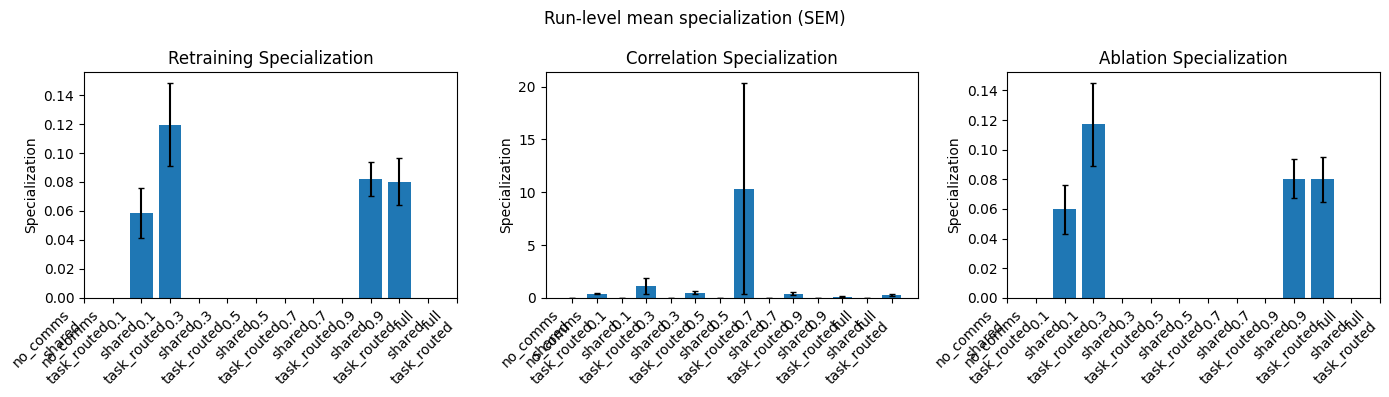

In [37]:
import matplotlib.pyplot as plt

if len(df_sorted) == 0:
    print("No results to plot. Run config cells and Build DataFrame first.")
else:
    run_level_plot = df_sorted.groupby(["run_id", "sparsity_label", "input_scheme"], sort=False)[metric_cols].agg(["mean", "sem"]).reset_index()
    run_level_plot["sparsity_order"] = run_level_plot["sparsity_label"].map(sparsity_order)
    run_level_plot = run_level_plot.sort_values(["sparsity_order", "input_scheme"])
    run_level_plot["x_label"] = run_level_plot["sparsity_label"] + "\n" + run_level_plot["input_scheme"]
    x_pos = np.arange(len(run_level_plot))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, m in enumerate(metric_cols):
        ax = axes[i]
        means = run_level_plot[m]["mean"].values
        sems = run_level_plot[m]["sem"].values
        ax.bar(x_pos, means, yerr=sems, capsize=2)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(run_level_plot["x_label"], rotation=45, ha="right")
        ax.set_ylabel("Specialization")
        ax.set_title(m.replace("_", " ").title())
        ax.set_ylim(0, None)
    plt.suptitle("Run-level mean specialization (SEM)")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3664421/1030906110.py:19: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  merged = run_keys.merge(sub, on=["run_id", "sparsity_label", "input_scheme"], how="left")
/tmp/ipykernel_3664421/1030906110.py:19: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  merged = run_keys.merge(sub, on=["run_id", "sparsity_label", "input_scheme"], how="left")
/tmp/ipykernel_3664421/1030906110.py:19: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  merged = run_keys.merge(sub, on=["run_id", "sparsity_label", "input_scheme"], how="left")


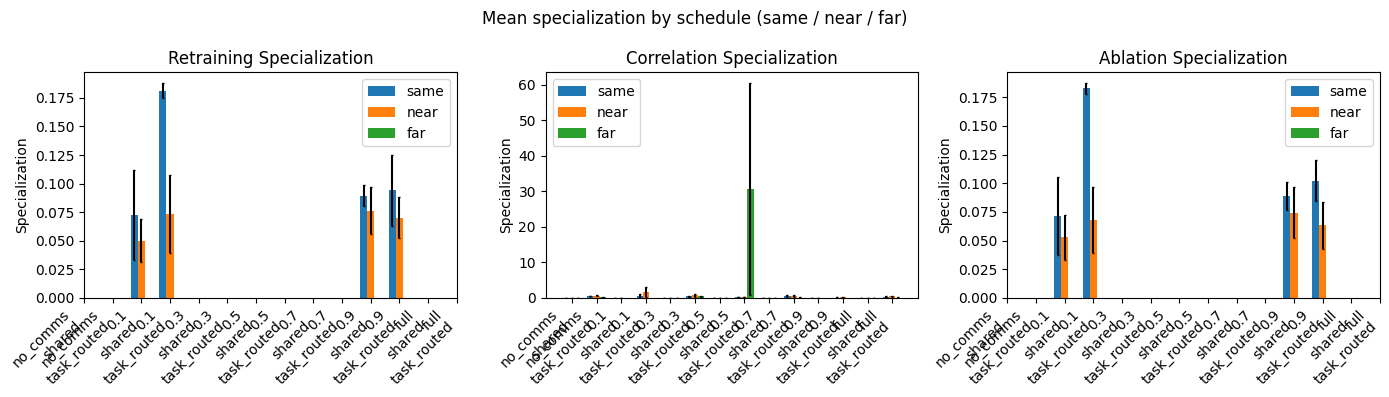

In [38]:
if len(df_sorted) == 0:
    print("No results to plot.")
else:
    _rlp = globals().get("run_level_plot")
    if _rlp is None or (hasattr(_rlp, "__len__") and len(_rlp) == 0):
        run_level_plot = df_sorted.groupby(["run_id", "sparsity_label", "input_scheme"], sort=False)[metric_cols].agg(["mean", "sem"]).reset_index()
        run_level_plot["sparsity_order"] = run_level_plot["sparsity_label"].map(sparsity_order)
        run_level_plot = run_level_plot.sort_values(["sparsity_order", "input_scheme"])
        run_level_plot["x_label"] = run_level_plot["sparsity_label"] + "\n" + run_level_plot["input_scheme"]
    fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
    schedules = ["same", "near", "far"]
    x = np.arange(len(run_level_plot))
    w = 0.25
    run_keys = run_level_plot[["run_id", "sparsity_label", "input_scheme"]]
    for i, m in enumerate(metric_cols):
        ax = axes2[i]
        for j, sched in enumerate(schedules):
            sub = by_schedule[by_schedule["schedule"] == sched]
            merged = run_keys.merge(sub, on=["run_id", "sparsity_label", "input_scheme"], how="left")
            means = merged[(m, "mean")].values
            sems = merged[(m, "sem")].values
            off = (j - 1) * w
            ax.bar(x + off, means, w, yerr=sems, label=sched, capsize=1)
        ax.set_xticks(x)
        ax.set_xticklabels(run_level_plot["x_label"], rotation=45, ha="right")
        ax.set_ylabel("Specialization")
        ax.set_title(m.replace("_", " ").title())
        ax.legend()
        ax.set_ylim(0, None)
    plt.suptitle("Mean specialization by schedule (same / near / far)")
    plt.tight_layout()
    plt.show()

## Save results

Save the gathered specialization metrics to disk so you can reload them without re-running the metric cells.

In [35]:
# Save results_list to CSV (same columns as df_results). Run "Build df_results" first if you want to save the deduplicated table.
out_dir = data_folder / "analysis"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "functional_specialization_extended.csv"

if not results_list:
    print("No results to save. Run the config cells above to compute metrics.")
else:
    df_save = pd.DataFrame(results_list).drop_duplicates(subset=["run_id", "participant"], keep="last")
    df_save.to_csv(out_path, index=False)
    print(f"Saved {len(df_save)} rows to {out_path}")

Saved 179 rows to /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/analysis/functional_specialization_extended.csv


## Check far for 0.1 and 0.9, then run one far participant each

Re-checks whether the 0.1 and 0.9 runs now have any **far** participants (e.g. after simulations finished). If yes, computes specialization metrics for **one far participant** per run (sp01 and sp09 shared) and appends to `results_list`.

In [ ]:
# Runs to check for far and run one participant each
run_ids_to_check = ["two_module_rnn_25_sp01_nb2", "two_module_rnn_25_sp09_nb2"]

for run_id in run_ids_to_check:
    r = next((x for x in runs if x["run_id"] == run_id), None)
    if r is None:
        path = resolve_run(run_id)
        if path is None:
            print(f"{run_id}: no folder, skip.")
            continue
        if run_id not in RUN_CONFIG_BY_PREFIX:
            print(f"{run_id}: not in RUN_CONFIG, skip.")
            continue
        sparsity_label, input_scheme = RUN_CONFIG_BY_PREFIX[run_id]
        r = {"run_id": run_id, "path": path, "sparsity_label": sparsity_label, "input_scheme": input_scheme}
        tasks_by_run[run_id] = get_tasks_for_run(r)

    far_tasks = [(rr, p, s) for rr, p, s in tasks_by_run.get(run_id, []) if s == "far"]
    if not far_tasks:
        print(f"{run_id}: no far participants yet (sim may still be running).")
        continue

    # Take first far participant only
    rr, participant, schedule = far_tasks[0]
    run_path = rr["path"]
    sparsity_label = rr["sparsity_label"]
    input_scheme = rr["input_scheme"]
    print(f"{run_id}: running one far participant: {participant}")

    # Remove existing result for this (run_id, participant) if any
    results_list[:] = [row for row in results_list if not (row["run_id"] == run_id and row["participant"] == participant)]

    settings = run_loader.load_settings(run_path)
    task_parameters = settings.get("task_parameters") or ann.setup_task_parameters()
    row = {"run_id": run_id, "participant": participant, "schedule": schedule, "sparsity_label": sparsity_label, "input_scheme": input_scheme, "retraining_specialization": None, "correlation_specialization": None, "ablation_specialization": None}
    has_state = (run_path / f"state_{participant}.pt").exists()
    if has_state:
        loader = build_loader_for_participant(df_trial, participant, task_parameters, batch_size=32, shuffle=True)
        wrapper = run_loader.build_wrapper_from_settings(settings, device=device)
        run_loader.load_wrapper_state(wrapper, run_path / f"state_{participant}.pt")
        wrapper = create_retraining_model_a1b2(wrapper, device=device)
        wrapper = train_probe_readout_a1b2(wrapper, loader, settings.get("condition", {}), n_epochs=n_epochs_probe, lr=1e-3, device=device)
        acc = eval_probe_readout_a1b2(wrapper, loader, device=device)
        row["retraining_specialization"] = float(retraining_specialization_scalar(acc[0, 0], acc[1, 0], acc[0, 1], acc[1, 1]))
        ab = compute_ablations_metric_a1b2(wrapper, loader, device=device)
        row["ablation_specialization"] = float(ab["ablation_specialization"])
    npz_path = run_path / f"sim_{participant}.npz"
    if npz_path.exists():
        with np.load(npz_path, allow_pickle=True) as data:
            if "hiddens_per_module" in data and "probes" in data:
                participant_data = {"hiddens_per_module": data["hiddens_per_module"], "probes": data["probes"], "inputs": data["inputs"]}
                out = compute_correlation_metric_a1b2(participant_data, n_samples=5)
                row["correlation_specialization"] = float(out["correlation_specialization"])
    results_list.append(row)
    print(f"  Appended. Total results: {len(results_list)}")